In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix, roc_curve
)
from sklearn.inspection import permutation_importance
from sklearn.model_selection import StratifiedKFold, cross_val_score, RandomizedSearchCV
import xgboost as xgb

DATA_PATH = Path("../data/WA_Fn-UseC_-Telco-Customer-Churn.csv")
df = pd.read_csv(DATA_PATH)

# Recreate the preprocessing required by the modeling notebook.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce").fillna(0)
df = df.drop(columns=["customerID"])

binary_maps = {
    "gender": {"Female": 0, "Male": 1},
    "Partner": {"No": 0, "Yes": 1},
    "Dependents": {"No": 0, "Yes": 1},
    "PhoneService": {"No": 0, "Yes": 1},
    "PaperlessBilling": {"No": 0, "Yes": 1},
    "Churn": {"No": 0, "Yes": 1},
}
for col, mapping in binary_maps.items():
    df[col] = df[col].map(mapping)

categorical_cols = [
    "MultipleLines", "InternetService", "OnlineSecurity",
    "OnlineBackup", "DeviceProtection", "TechSupport",
    "StreamingTV", "StreamingMovies", "Contract", "PaymentMethod"
]
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

X = df.drop(columns=["Churn"])
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
scaler = StandardScaler()
X_train[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test[numeric_cols] = scaler.transform(X_test[numeric_cols])

addon_yes_cols = [
    "OnlineSecurity_Yes", "OnlineBackup_Yes", "DeviceProtection_Yes",
    "TechSupport_Yes", "StreamingTV_Yes", "StreamingMovies_Yes"
]
X_train["TotalAddons"] = X_train[addon_yes_cols].sum(axis=1)
X_test["TotalAddons"] = X_test[addon_yes_cols].sum(axis=1)

redundant_cols = [
    "OnlineSecurity_No internet service",
    "OnlineBackup_No internet service",
    "DeviceProtection_No internet service",
    "TechSupport_No internet service",
    "StreamingTV_No internet service",
    "StreamingMovies_No internet service",
]
X_train = X_train.drop(columns=redundant_cols + addon_yes_cols +
                       ["MultipleLines_No phone service", "TotalCharges"])
X_test = X_test.drop(columns=redundant_cols + addon_yes_cols +
                      ["MultipleLines_No phone service", "TotalCharges"])

X_train = X_train.astype(float)
X_test = X_test.astype(float)


Four classifiers were compared:

- Logistic Regression
- Decision Tree
- Random Forest
- XGBoost

Because churn is imbalanced, the original workflow used class weighting / `scale_pos_weight` and emphasized **recall** as the business objective: missing an actual churner was considered more costly than sending an unnecessary retention offer.


In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb

models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=42
    ),

    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        class_weight="balanced",
        random_state=42
    ),

    "Random Forest": RandomForestClassifier(
        n_estimators=100,
        max_depth=10,
        max_features="sqrt",
        class_weight="balanced",
        random_state=42
    ),

    "XGBoost": xgb.XGBClassifier(
        n_estimators=100,
        learning_rate=0.1,
        max_depth=3,
        reg_lambda=1,
        reg_alpha=0,
        scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
        random_state=42
    )
}

predictions = {}
probabilities = {}

for name, estimator in models.items():
    estimator.fit(X_train, y_train)
    predictions[name] = estimator.predict(X_test)
    probabilities[name] = estimator.predict_proba(X_test)[:, 1]

print("All four models trained successfully.")


All four models trained successfully.


In [3]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix
)

results = []

for name in models:
    y_pred = predictions[name]
    y_proba = probabilities[name]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

results_df = pd.DataFrame(results).sort_values("ROC-AUC", ascending=False)
display(results_df.round(3))


,Model,Accuracy,Precision,Recall,F1,ROC-AUC
3,XGBoost,0.740,0.507,0.810,0.623,0.842
0,Logistic Regression,0.737,0.503,0.775,0.611,0.839
2,Random Forest,0.749,0.519,0.770,0.620,0.839
1,Decision Tree,0.743,0.510,0.781,0.617,0.832


In [4]:
for name in models:
    print(f"\n{'=' * 60}\n{name}\n{'=' * 60}")
    print(
        classification_report(
            y_test,
            predictions[name],
            target_names=["No Churn", "Churn"]
        )
    )



Logistic Regression
              precision    recall  f1-score   support

    No Churn       0.90      0.72      0.80      1035
       Churn       0.50      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.79      0.74      0.75      1409


Decision Tree
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.76      1409


Random Forest
              precision    recall  f1-score   support

    No Churn       0.90      0.74      0.81      1035
       Churn       0.52      0.77      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.72      1409
weighted avg       0.80

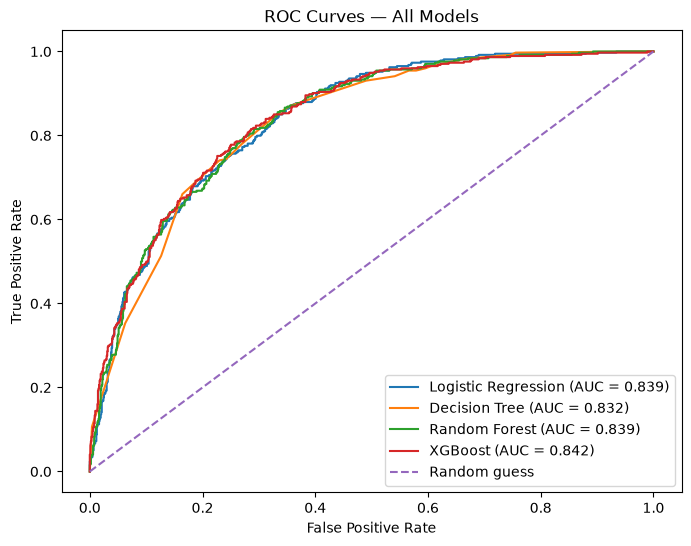

In [5]:
# ROC curves
from sklearn.metrics import roc_curve

plt.figure(figsize=(8, 6))

for name in models:
    fpr, tpr, _ = roc_curve(y_test, probabilities[name])
    auc = roc_auc_score(y_test, probabilities[name])
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All Models")
plt.legend()
plt.show()


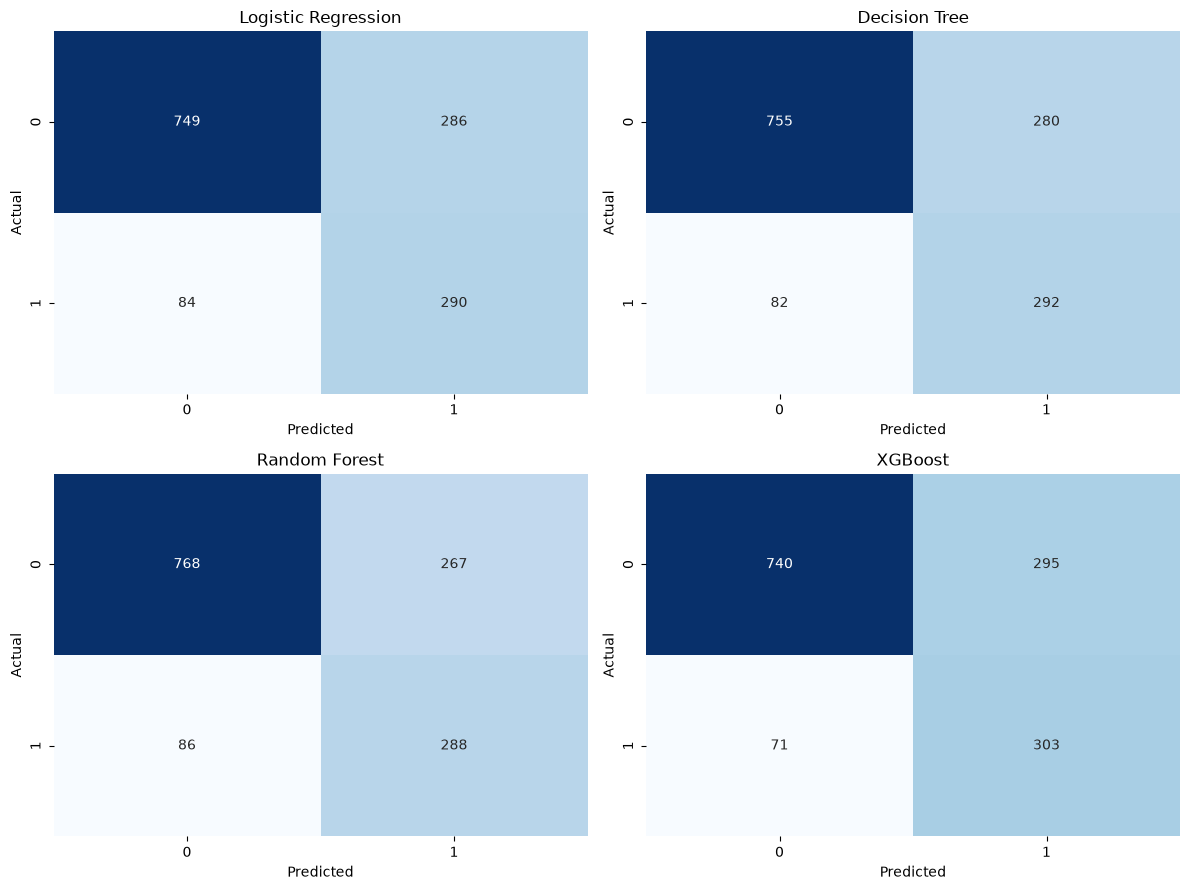

In [6]:
# Confusion matrices
fig, axes = plt.subplots(2, 2, figsize=(12, 9))

for ax, (name, y_pred) in zip(axes.ravel(), predictions.items()):
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        cbar=False,
        ax=ax
    )
    ax.set_title(name)
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")

plt.tight_layout()
plt.show()


### Feature importance

The original notebook compared:

- Logistic Regression coefficients / odds ratios
- Decision Tree Gini importance
- Decision Tree permutation importance
- Random Forest feature importance
- XGBoost feature importance

The main synthesis was that **contract length and tenure** were consistently important across models. `MonthlyCharges` was highly important for Logistic Regression and Random Forest, while it received less importance in XGBoost, likely because correlated information was captured earlier through other features.


In [7]:
# Logistic Regression coefficients
lr = models["Logistic Regression"]

coef_df = pd.DataFrame({
    "feature": X_train.columns,
    "weight": lr.coef_[0]
})
coef_df["odds_ratio"] = np.exp(coef_df["weight"])

display(coef_df.sort_values("weight", ascending=False).head(15))


,feature,weight,odds_ratio
7,MonthlyCharges,1.795184,6.020584
10,InternetService_No,0.731346,2.077875
14,PaymentMethod_Electronic check,0.434945,1.544878
6,PaperlessBilling,0.367727,1.444448
1,SeniorCitizen,0.166729,1.181434
15,PaymentMethod_Mailed check,0.073113,1.075852
0,gender,0.045684,1.046744
2,Partner,0.018639,1.018814
8,MultipleLines_Yes,-0.000341,0.999660
13,PaymentMethod_Credit card (automatic),-0.017866,0.982293


In [8]:
# Tree-based feature importance
tree = models["Decision Tree"]

tree_importance = pd.DataFrame({
    "feature": X_train.columns,
    "gini_importance": tree.feature_importances_
}).sort_values("gini_importance", ascending=False)

display(tree_importance.head(15))


,feature,gini_importance
12,Contract_Two year,0.406036
11,Contract_One year,0.253931
9,InternetService_Fiber optic,0.111769
4,tenure,0.102335
7,MonthlyCharges,0.066934
10,InternetService_No,0.020783
14,PaymentMethod_Electronic check,0.017203
5,PhoneService,0.014215
0,gender,0.003945
3,Dependents,0.002070


In [9]:
from sklearn.inspection import permutation_importance

perm = permutation_importance(
    tree,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42
)

perm_df = pd.DataFrame({
    "feature": X_train.columns,
    "importance_mean": perm.importances_mean,
    "importance_std": perm.importances_std
}).sort_values("importance_mean", ascending=False)

display(perm_df.head(15))


,feature,importance_mean,importance_std
12,Contract_Two year,0.053371,0.005667
11,Contract_One year,0.045067,0.008435
9,InternetService_Fiber optic,0.026615,0.008877
4,tenure,0.017814,0.003336
10,InternetService_No,0.014833,0.002793
14,PaymentMethod_Electronic check,0.002910,0.000976
7,MonthlyCharges,0.001207,0.001272
0,gender,0.000000,0.000000
2,Partner,0.000000,0.000000
1,SeniorCitizen,0.000000,0.000000


In [10]:
rf_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": models["Random Forest"].feature_importances_
}).sort_values("importance", ascending=False)

xgb_importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": models["XGBoost"].feature_importances_
}).sort_values("importance", ascending=False)

print("Random Forest:")
display(rf_importance.head(10))

print("XGBoost:")
display(xgb_importance.head(10))


Random Forest:


,feature,importance
4,tenure,0.236274
12,Contract_Two year,0.156872
7,MonthlyCharges,0.154351
9,InternetService_Fiber optic,0.094688
11,Contract_One year,0.074451
14,PaymentMethod_Electronic check,0.053305
16,TotalAddons,0.047988
10,InternetService_No,0.037717
6,PaperlessBilling,0.027825
0,gender,0.019435


XGBoost:


,feature,importance
12,Contract_Two year,0.314740
11,Contract_One year,0.238198
10,InternetService_No,0.132348
9,InternetService_Fiber optic,0.112701
14,PaymentMethod_Electronic check,0.042601
4,tenure,0.041096
6,PaperlessBilling,0.020168
3,Dependents,0.013957
8,MultipleLines_Yes,0.013545
7,MonthlyCharges,0.012041


### Cross-validation and XGBoost tuning

In [11]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

skf = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

cv_results = []

for name, estimator in models.items():
    scores = cross_val_score(
        estimator,
        X_train,
        y_train,
        cv=skf,
        scoring="roc_auc"
    )

    cv_results.append({
        "Model": name,
        "Mean CV AUC": scores.mean(),
        "Std CV AUC": scores.std()
    })

cv_df = pd.DataFrame(cv_results).sort_values("Mean CV AUC", ascending=False)
display(cv_df.round(4))


,Model,Mean CV AUC,Std CV AUC
3,XGBoost,0.8463,0.0121
0,Logistic Regression,0.8433,0.0114
2,Random Forest,0.8394,0.0111
1,Decision Tree,0.8241,0.0091


In [12]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    "n_estimators": [50, 100, 150, 200, 300],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.05, 0.1, 0.15, 0.2],
    "reg_lambda": [0.1, 1, 5, 10],
    "reg_alpha": [0, 0.1, 1, 5],
    "subsample": [0.7, 0.8, 0.9, 1.0]
}

xgb_base = xgb.XGBClassifier(
    scale_pos_weight=(y_train == 0).sum() / (y_train == 1).sum(),
    random_state=42
)

random_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=30,
    cv=skf,
    scoring="roc_auc",
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train, y_train)

print("Best parameters:")
print(random_search.best_params_)
print(f"Best CV AUC: {random_search.best_score_:.4f}")


Best parameters:
{'subsample': 0.8, 'reg_lambda': 1, 'reg_alpha': 0.1, 'n_estimators': 100, 'max_depth': 3, 'learning_rate': 0.05}
Best CV AUC: 0.8474


In [13]:
# Evaluate the tuned XGBoost on the held-out test set.
tuned_xgb = random_search.best_estimator_

tuned_pred = tuned_xgb.predict(X_test)
tuned_proba = tuned_xgb.predict_proba(X_test)[:, 1]

tuned_metrics = {
    "Accuracy": accuracy_score(y_test, tuned_pred),
    "Precision": precision_score(y_test, tuned_pred),
    "Recall": recall_score(y_test, tuned_pred),
    "F1": f1_score(y_test, tuned_pred),
    "ROC-AUC": roc_auc_score(y_test, tuned_proba)
}

display(pd.DataFrame([tuned_metrics], index=["Tuned XGBoost"]).round(3))

print(classification_report(
    y_test,
    tuned_pred,
    target_names=["No Churn", "Churn"]
))


,Accuracy,Precision,Recall,F1,ROC-AUC
Tuned XGBoost,0.739,0.505,0.799,0.619,0.843


              precision    recall  f1-score   support

    No Churn       0.91      0.72      0.80      1035
       Churn       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



## Final Model Selection

The original notebook's final conclusion was:

- Logistic Regression, Random Forest, and XGBoost had broadly similar cross-validated AUC performance.
- Decision Tree was consistently the weakest model.
- XGBoost had the highest mean CV AUC among the compared models.
- Hyperparameter tuning produced only a very small improvement, supporting the conclusion that performance was more constrained by available feature signal than by model choice.
- **Recommendation: tuned XGBoost**, especially when recall is prioritized for the churn-retention use case.

